In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import draw_latent_z, calc_avg_pk
from models import nuGANGenerator
from collections import OrderedDict
t1 = time.time()

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (12, 8),
         'axes.labelsize':14,
         'axes.titlesize':14,
         'xtick.labelsize':16,
         'ytick.labelsize':16}
pylab.rcParams.update(params)

## Set args and load model

In [2]:
target_maps_path = "./data/scaled_density_contrast_maps.npy"
target_maps = np.load(target_maps_path)
model_path = "./checkpoints/best_model_state_dict.pt"
device = "cuda:0"
mchn = 2
nz = 200

model = nuGANGenerator(nz, mchn).to(device)
state_dict = torch.load(model_path, weights_only=True, map_location=device)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v
model.load_state_dict(new_state_dict)
model.eval()

nuGANGenerator(
  (linear): Linear(in_features=204, out_features=131072, bias=True)
  (deconvs): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [3]:
num_maps = 1000
savedir = f"./results/graphs"
savepath_pk = f"{savedir}/avg_pk_over_{num_maps}_maps.png"
nu_info = {
    0.0: (0, 0 + num_maps),
    0.1: (3000, 3000 + num_maps),
    0.4: (6000, 6000 + num_maps),
    0.8: (9000, 9000 + num_maps),
    1.2: (12000, 12000 + num_maps),
}

synthetic_maps = {}
actual_maps = {}
targ_pk_by_nu = {}
gen_pk_by_nu = {}
tk_by_nu = {}
k = None

for nu,ranges in nu_info.items():
        
        #---Generate maps with nuGAN
        params = torch.Tensor(num_maps*[nu]).to(device)
        z = draw_latent_z(prior="gaussian",
                  sample_shape=(len(params),200),
                  device=device,
                  df=None)
        gen_maps_numass = model(z, params, 2).cpu().detach().squeeze().numpy()        
        k, pksp = calc_avg_pk(gen_maps_numass)
        synthetic_maps[nu] = gen_maps_numass
        gen_pk_by_nu[nu] = pksp

        #---Read target maps
        targ_maps_numass = target_maps[ranges[0]:ranges[1]]
        k, pkst = calc_avg_pk(targ_maps_numass)
        actual_maps[nu] = targ_maps_numass
        targ_pk_by_nu[nu] = pkst

        print(f"Processed neutrino mass {nu}")
        tk_by_nu[nu] = pksp/pkst

Processed neutrino mass 0.0
Processed neutrino mass 0.1
Processed neutrino mass 0.4
Processed neutrino mass 0.8
Processed neutrino mass 1.2


## 1 - Average P(k) and T(k)

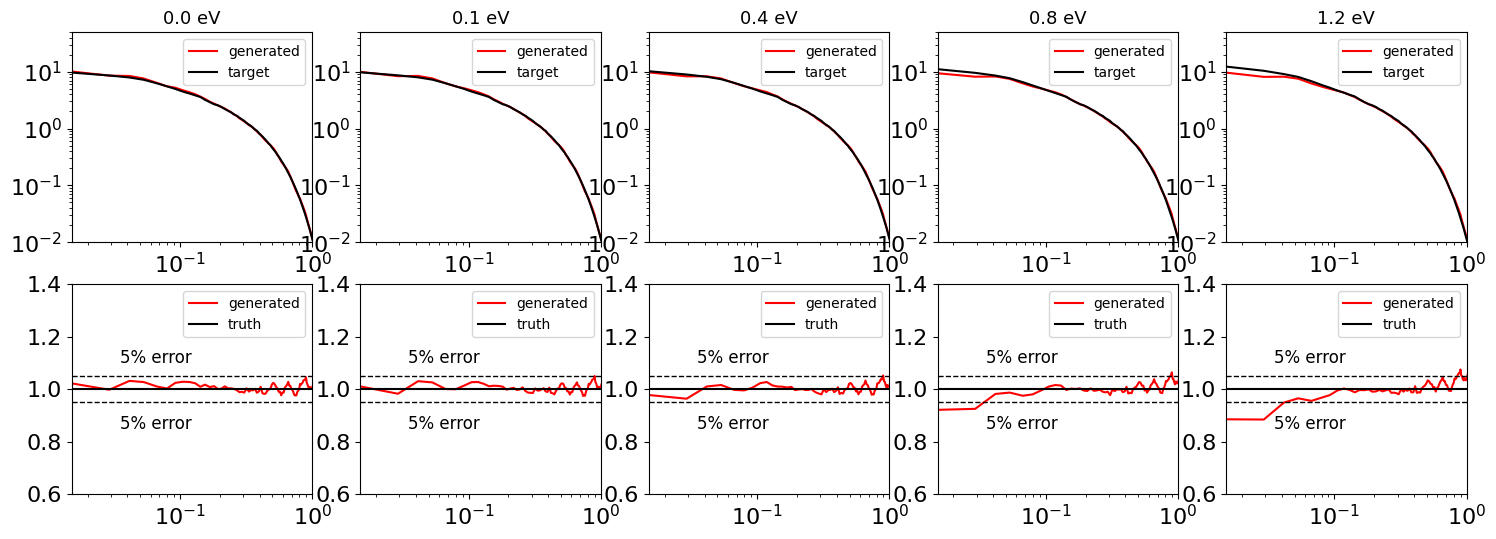

In [6]:
limit_yrange = 'n'
log_yrange = 'n'

#---Top panel (Pk) params
ax_xlims = (k[0], 1)
ax_ylims = (0.01,50)
delta = 0.4

#---Bottom panel (Tk) params
bx_xlims = ax_xlims
bx_ylims = (1.0-delta,1.0+delta)
hlinevals = (1.0-0.05, 1.0+0.05)
text = f"5% error"
text_loc_delta = 0.01
xx,yy1,yy2 = 0.035, 1.1, 0.85


fig, ((ax1,ax2,ax3,ax4,ax5),(bx1,bx2,bx3,bx4,bx5)) = plt.subplots(2,5,figsize=(18,6))

#---Plot P(k)

ax1.loglog(k, gen_pk_by_nu[0.0], c='r', ls='-', label='generated')
ax1.loglog(k, targ_pk_by_nu[0.0], c='k', ls='-', label='target')
ax1.set_title(f'0.0 eV', fontsize=13)
ax1.legend(fontsize=10)
ax1.set_xlim(ax_xlims[0], ax_xlims[1])
ax1.set_ylim(ax_ylims[0], ax_ylims[1])

ax2.loglog(k, gen_pk_by_nu[0.1], c='r', ls='-', label='generated')
ax2.loglog(k, targ_pk_by_nu[0.1], c='k', ls='-', label='target')
ax2.set_title(f'0.1 eV', fontsize=13)
ax2.legend(fontsize=10)
ax2.set_xlim(ax_xlims[0], ax_xlims[1])
ax2.set_ylim(ax_ylims[0], ax_ylims[1])

ax3.loglog(k, gen_pk_by_nu[0.4], c='r', ls='-', label='generated')
ax3.loglog(k, targ_pk_by_nu[0.4], c='k', ls='-', label='target')
ax3.set_title(f'0.4 eV', fontsize=13)
ax3.legend(fontsize=10)
ax3.set_xlim(ax_xlims[0], ax_xlims[1])
ax3.set_ylim(ax_ylims[0], ax_ylims[1])

ax4.loglog(k, gen_pk_by_nu[0.8], c='r', ls='-', label='generated')
ax4.loglog(k, targ_pk_by_nu[0.8], c='k', ls='-', label='target')
ax4.set_title(f'0.8 eV', fontsize=13)
ax4.legend(fontsize=10)
ax4.set_xlim(ax_xlims[0], ax_xlims[1])
ax4.set_ylim(ax_ylims[0], ax_ylims[1])

ax5.loglog(k, gen_pk_by_nu[1.2], c='r', ls='-', label='generated')
ax5.loglog(k, targ_pk_by_nu[1.2], c='k', ls='-', label='target')
ax5.set_title(f'1.2 eV', fontsize=13)
ax5.legend(fontsize=10)
ax5.set_xlim(ax_xlims[0], ax_xlims[1])
ax5.set_ylim(ax_ylims[0], ax_ylims[1])



#---Plot P(k)

bx1.plot(k, (tk_by_nu[0.0])**0.5, c='r', ls='-', label='generated')
bx1.axhline(1, c='k', label='truth')
bx1.axhline(hlinevals[0], c='k', ls='--', lw=1)
bx1.axhline(hlinevals[1], c='k', ls='--', lw=1)
bx1.text(x=xx, y=yy1, s=text, size=12)
bx1.text(x=xx, y=yy2, s=text, size=12)
bx1.legend(fontsize=10)
bx1.set_xlim(bx_xlims[0], bx_xlims[1])
bx1.set_ylim(bx_ylims[0], bx_ylims[1])
bx1.set_xscale('log')

bx2.plot(k, (tk_by_nu[0.1])**0.5, c='r', ls='-', label='generated')
bx2.axhline(1, c='k', label='truth')
bx2.axhline(hlinevals[0], c='k', ls='--', lw=1)
bx2.axhline(hlinevals[1], c='k', ls='--', lw=1)
bx2.text(x=xx, y=yy1, s=text, size=12)
bx2.text(x=xx, y=yy2, s=text, size=12)
bx2.legend(fontsize=10)
bx2.set_xlim(bx_xlims[0], bx_xlims[1])
bx2.set_ylim(bx_ylims[0], bx_ylims[1])
bx2.set_xscale('log')

bx3.plot(k, (tk_by_nu[0.4])**0.5, c='r', ls='-', label='generated')
bx3.axhline(1, c='k', label='truth')
bx3.axhline(hlinevals[0], c='k', ls='--', lw=1)
bx3.axhline(hlinevals[1], c='k', ls='--', lw=1)
bx3.text(x=xx, y=yy1, s=text, size=12)
bx3.text(x=xx, y=yy2, s=text, size=12)
bx3.legend(fontsize=10)
bx3.set_xlim(bx_xlims[0], bx_xlims[1])
bx3.set_ylim(bx_ylims[0], bx_ylims[1])
bx3.set_xscale('log')

bx4.plot(k, (tk_by_nu[0.8])**0.5, c='r', ls='-', label='generated')
bx4.axhline(1, c='k', label='truth')
bx4.axhline(hlinevals[0], c='k', ls='--', lw=1)
bx4.axhline(hlinevals[1], c='k', ls='--', lw=1)
bx4.text(x=xx, y=yy1, s=text, size=12)
bx4.text(x=xx, y=yy2, s=text, size=12)
bx4.legend(fontsize=10)
bx4.set_xlim(bx_xlims[0], bx_xlims[1])
bx4.set_ylim(bx_ylims[0], bx_ylims[1])
bx4.set_xscale('log')

bx5.plot(k, (tk_by_nu[1.2])**0.5, c='r', ls='-', label='generated')
bx5.axhline(1, c='k', label='truth')
bx5.axhline(hlinevals[0], c='k', ls='--', lw=1)
bx5.axhline(hlinevals[1], c='k', ls='--', lw=1)
bx5.text(x=xx, y=yy1, s=text, size=12)
bx5.text(x=xx, y=yy2, s=text, size=12)
bx5.legend(fontsize=10)
bx5.set_xlim(bx_xlims[0], bx_xlims[1])
bx5.set_ylim(bx_ylims[0], bx_ylims[1])
bx5.set_xscale('log')

#fig.savefig(savepath_pk, dpi=100)
fig.show()

## 2 - Comparing actual and synthetic maps for various neutrino masses

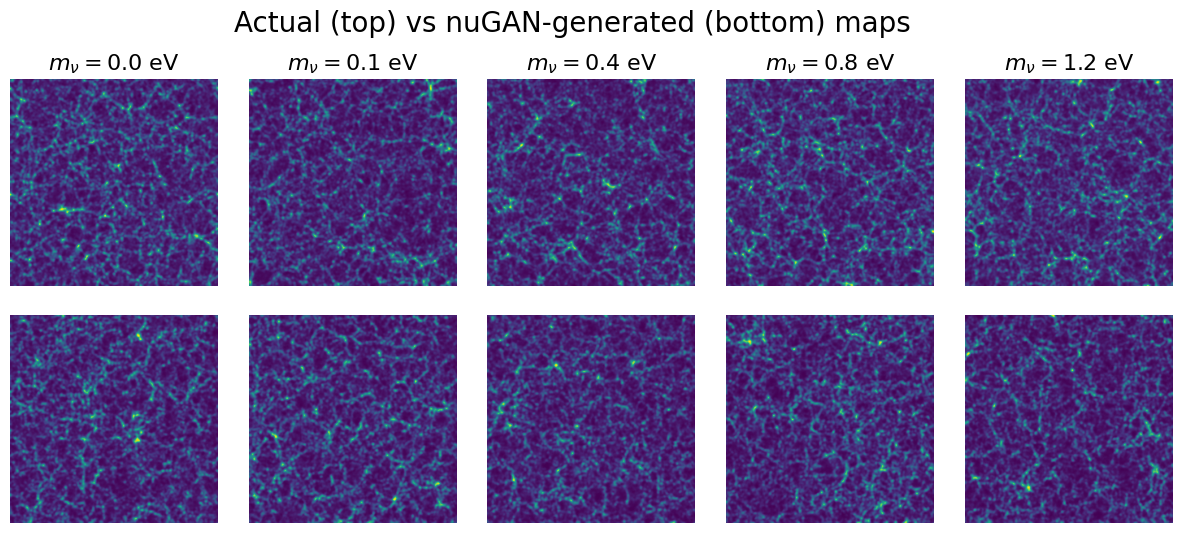

In [7]:
savepath_comparative_maps = f"{savedir}/sample_maps_comparison.png"
fig, axes = plt.subplots(2,5,figsize=(15,6), gridspec_kw={'hspace': 0.05, 'wspace': 0.15})
fig.suptitle("Actual (top) vs nuGAN-generated (bottom) maps", fontsize=20)
# fig.subplots_adjust(left=0.05,
#                     bottom=0.05,
#                     right=0.95,
#                     top=0.92,
#                     wspace=0.15,
#                     hspace=-0.02)

for i, nu in enumerate(nu_info.keys()):
    gen_map = synthetic_maps[nu][np.random.choice(synthetic_maps[nu].shape[0])]
    act_map = actual_maps[nu][np.random.choice(actual_maps[nu].shape[0])]

    axes[0, i].imshow(act_map)
    axes[0, i].set_title(f"$m_\\nu = {nu}$ eV", fontsize=16)
    axes[0, i].axis("off")

    axes[1, i].imshow(gen_map)
    axes[1, i].axis("off")

fig.show()
#fig.tight_layout()
#fig.savefig(savepath_comparative_maps, dpi=100)

## 3 - Pixel peaks distribution comparison

In [51]:
import scipy.ndimage
def peak_count(X, neighborhood_size=5, threshold=0.5):
    """
    Peak count for a 2D or a 3D square image
    :param X: numpy array shape [n,n] or [n,n,n]
    :param neighborhood_size: size of the local neighborhood that should be filtered
    :param threshold: minimum distance betweent the minimum and the maximum to be considered a local maximum. Helps remove noise peaks (0.5 since the number of particle is supposed to be an integer)
    :return: vector of peaks found in the array (int)
    """
    size = len(X.shape)
    if len(X.shape) == 1:
        pass
    elif size==2:
        assert(X.shape[0]==X.shape[1])
    elif size==3:
        assert(X.shape[0]==X.shape[1]==X.shape[2])
    else:
        raise Exception(" [!] Too many dimensions")

    data_max = scipy.ndimage.maximum_filter(X, neighborhood_size, mode="reflect")
    #maxima = (X == data_max)
    maxima = np.isclose(X, data_max, rtol=1e-9, atol=1e-9)
    if threshold != 0:
        data_min = scipy.ndimage.minimum_filter(X, neighborhood_size, mode="reflect")
        diff = ((data_max - data_min) >= threshold)
        #maxima[diff == 0] = 0
        maxima = maxima & diff
    
    return np.extract(maxima, X)

def get_pixel_peak_histogram(maps_dict, nbins=30, avg_type="median", neighborhood_size=5, threshold=0.25):
    """
    Median pixel histogram for 2D cosmic web images
    :param image_dict: a dictionary {0.0:[img1,img2,...], 0.4:[img1,img2,...], ...]} containing 2D images
    :param nbins: Number of bins desired in the histogram
    :param avg_type: Whether mean is desired or median
    :return: tuple->(dict,ndarray), where dict is {0.0:counts, 0.1:counts, ...} and
                                          ndarray is the array of center of bin edges
    """
    
    #----Get binning for all maps for each neutrino mass
    all_counts = {0.0:[],0.1:[],0.4:[],0.8:[],1.2:[]}
    for sample in range(num_maps):
        for nu in nu_info.keys():    
            peak_counts  = peak_count(maps_dict[nu][sample],
                                      neighborhood_size=neighborhood_size,
                                      threshold=threshold)
            counts, bins = np.histogram(peak_counts, bins=nbins, range=(-1,1))
            all_counts[nu].append(counts)
            if sample==0:
                all_bins = bins
            #if (sample+1)%100==0 or (sample+1)==num_maps:
                #print(f"Processed {sample+1}/{num_maps} samples for neutrino mass {nu}")
    #print()

    #----Center the bins
    bincenters = []
    for i in range(len(all_bins)-1):
        bin_center = (all_bins[i]+all_bins[i+1])/2
        bincenters.append(bin_center)
    bincenters = np.array(bincenters)

    #----Get median counts for each neutrino mass
    central_counts = {0.0:0, 0.1:0, 0.4:0, 0.8:0, 1.2:0}
    for nu in maps_dict.keys():
        if avg_type=="median":
            central_hist = np.median(np.array(all_counts[nu]), axis=0)
        elif avg_type=="mean":
            central_hist = np.mean(np.array(all_counts[nu]), axis=0)
        central_counts[nu] = central_hist
        
    return all_counts, central_counts, bincenters

print("Processing synthetic samples")
all_counts_synth, avg_counts_synth, bin_centers_synth = get_pixel_peak_histogram(synthetic_maps,
                                                                                 nbins=50,
                                                                                 avg_type="median",
                                                                                 neighborhood_size=5,
                                                                                 threshold=0.25)

print("Processing actual samples")
all_counts_act, avg_counts_act, bin_centers_act = get_pixel_peak_histogram(actual_maps,
                                                                                 nbins=50,
                                                                                 avg_type="median",
                                                                                 neighborhood_size=5,
                                                                                 threshold=0.25)

Processing synthetic samples
Processing actual samples


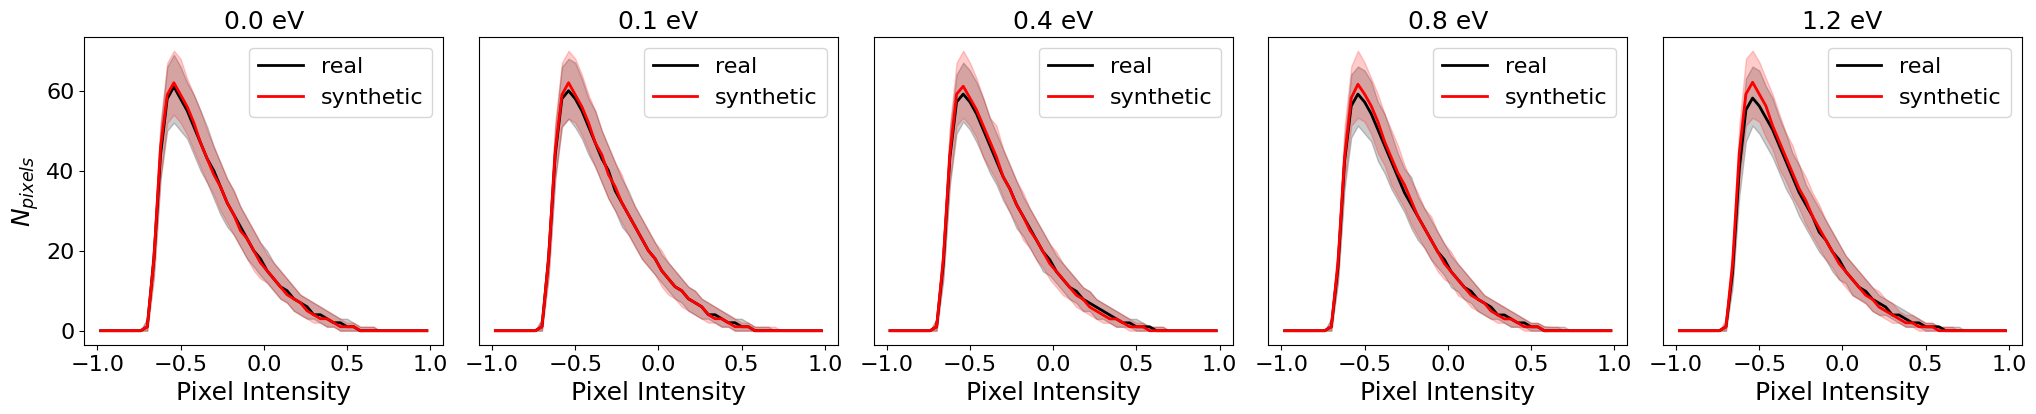

In [66]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4))
fig.subplots_adjust(wspace=0.1)

for nu, sp in zip(list(nu_info.keys()),(ax,bx,cx,dx,ex)):
        
    q16r = np.quantile(np.array(all_counts_act[nu]), q=0.16, axis=0)
    q84r = np.quantile(np.array(all_counts_act[nu]), q=0.84, axis=0)
    sp.plot(bin_centers_act, avg_counts_act[nu], c='k', lw=2, label='real')
    sp.fill_between(bin_centers_act, q16r, q84r, alpha=0.2, color='k')
    
    q16f = np.quantile(np.array(all_counts_synth[nu]), q=0.16, axis=0)
    q84f = np.quantile(np.array(all_counts_synth[nu]), q=0.84, axis=0)
    sp.plot(bin_centers_synth, avg_counts_synth[nu], c='r', lw=2, label='synthetic')
    sp.fill_between(bin_centers_synth, q16f, q84f, alpha=0.2, color='r')

    sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.legend(fontsize=16)
    sp.set_xlabel("Pixel Intensity", fontsize=18)
    sp.set_title(f"{nu} eV", fontsize=18)
    if sp is not ax:
        sp.set_yticks([])
    else:
        sp.set_ylabel(r"$N_{pixels}$", fontsize=18)

plt.show()

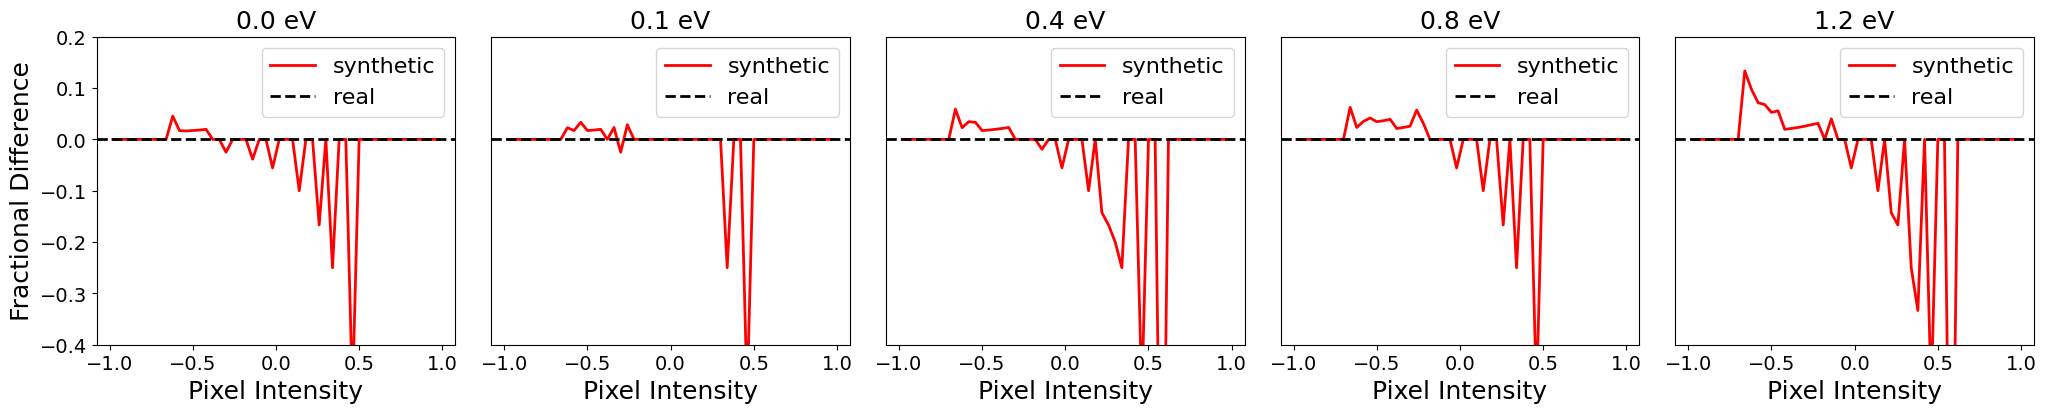

In [72]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4))
fig.subplots_adjust(wspace=0.1)
option = 2
for nu, sp in zip(nu_info.keys(),(ax,bx,cx,dx,ex)):

    if option==1:
        real = avg_counts_act[nu]
        synth = avg_counts_synth[nu]
        mask = real > 0
        res = np.full_like(real, np.nan, dtype=float)
        res[mask] = (synth[mask] - real[mask]) / real[mask]
        #print(res)

    elif option==2:
        res = np.divide(
                    avg_counts_synth[nu] - avg_counts_act[nu],
                    avg_counts_act[nu],
                    out=np.zeros_like(avg_counts_act[nu], dtype=float),
                    where=avg_counts_act[nu] > 0
                )
        #print(res)
    elif option==3:
        res = (avg_counts_synth[nu] - avg_counts_act[nu])/avg_counts_act[nu]


    sp.plot(bin_centers_act, res, c='r', lw=2, label='synthetic')
    sp.axhline(0.0, c='k', ls='--', lw=2, label='real')

    sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.legend(fontsize=16)
    if sp is not ax:
        sp.set_yticks([])
    else:
        sp.set_ylabel(r"Fractional Difference", fontsize=18)
    sp.set_title(f"{nu} eV", fontsize=18)
    sp.set_xlabel("Pixel Intensity", fontsize=18)
    sp.tick_params(axis='both', which='major', labelsize=14)
    sp.set_ylim(-0.4,0.2)
    #sp.set_xscale('log')
    #sp.set_yscale('log')
    #sp.set_xlim(-0.5,1)

#plt.savefig("new_pixel_peak_histograms_error.png", dpi=72)
plt.show()

## 4 - Pixel intensity distribution

In [ ]:
def get_single_histogram_fit(data, bins):
    a = np.histogram(data, bins=bins)
    tops = a[0]
    bin_edges = a[1]
    bin_centers = []
    for i in range(len(tops)):
        bin_center = (bin_edges[i] + bin_edges[i+1])/2
        bin_centers.append(bin_center)
    return np.array(bin_centers), np.array(tops)

def get_median_histogram_fit(data, bins):
    avg_tops = []
    for i in range(len(data)):
        bc, tops = get_single_histogram_fit(data[i], bins)
        avg_tops.append(tops)
    avg_tops = np.array(avg_tops)
    return bc, np.median(avg_tops,axis=0)

def get_mean_histogram_fit(data, bins):
    avg_tops = []
    for i in range(len(data)):
        bc, tops = get_single_histogram_fit(data[i], bins)
        avg_tops.append(tops)
    avg_tops = np.array(avg_tops)
    return bc, np.mean(avg_tops,axis=0)

mybins = np.linspace(-1,1,50)

KeyboardInterrupt: 

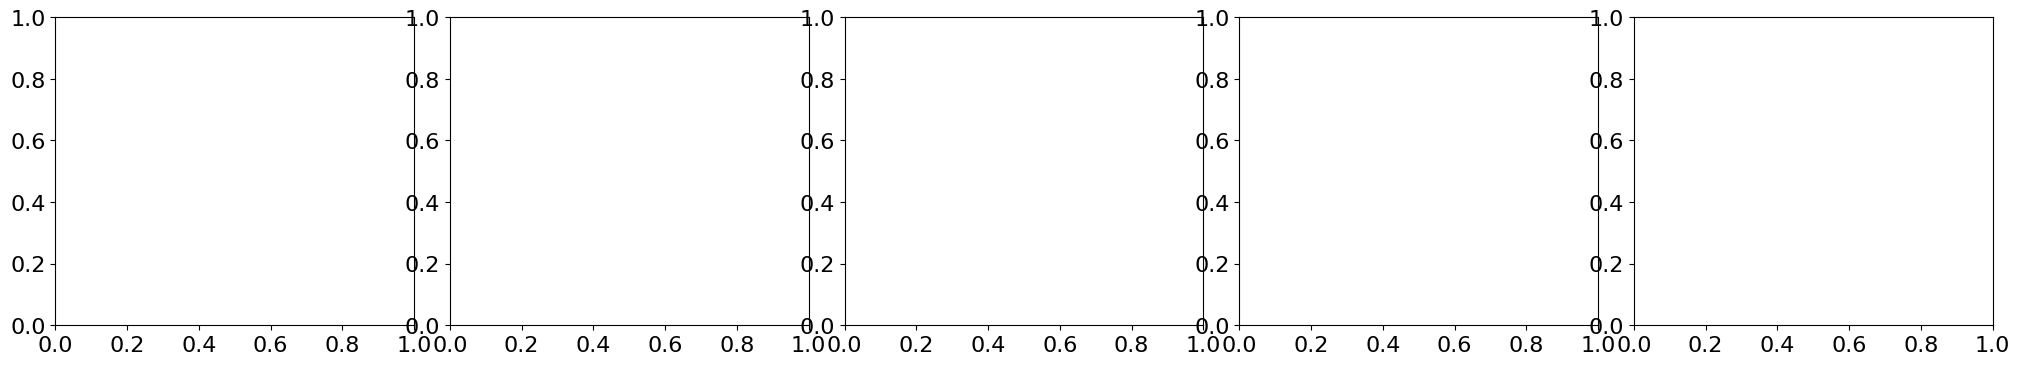

In [74]:
fig, (ax,bx,cx,dx,ex) = plt.subplots(1,5, figsize=(25,4))
fig.subplots_adjust(wspace=0.1)

for nu, sp in zip(nu_info.keys(),(ax,bx,cx,dx,ex)):
    
    xx_synth, pixel_hist_synth = get_median_histogram_fit(synthetic_maps[nu].flatten(), bins=mybins)
    xx_act, pixel_hist_act = get_median_histogram_fit(actual_maps[nu].flatten(), bins=mybins)
    
    sp.plot(xx_synth, pixel_hist_synth, marker=None, c= 'k', label='synthetic')
    sp.plot(xx_act, pixel_hist_act, marker=None, c= 'k', label='actual')
    #sp.set_xticks([-1,-0.5,0,0.5,1.0])
    sp.legend(fontsize=16)
    #sp.set_xlabel("Pixel Intensity", fontsize=18)
    #sp.set_title(f"{nu} eV", fontsize=18)
    #if sp is not ax:
    #    sp.set_yticks([])
    #else:
    #    sp.set_ylabel(r"$N_{pixels}$", fontsize=18)
plt.show()

In [ ]:
#----FAKES
i=34
xx0sf, yy0sf = get_histogram_fit(fakes[0.0][i].flatten(), bins=mybins)
xx1sf, yy1sf = get_histogram_fit(fakes[0.1][i].flatten(), bins=mybins)
xx4sf, yy4sf = get_histogram_fit(fakes[0.4][i].flatten(), bins=mybins)
#xx8sf, yy8sf = get_histogram_fit(fakes[0.8][i].flatten(), bins=mybins)
#xx12sf, yy12sf = get_histogram_fit(fakes[1.2][i].flatten(), bins=mybins)

xx0mf, yy0mf = get_median_histogram_fit(fakes[0.0], bins=mybins)
xx1mf, yy1mf = get_median_histogram_fit(fakes[0.1], bins=mybins)
xx4mf, yy4mf = get_median_histogram_fit(fakes[0.4], bins=mybins)
#xx8mf, yy8mf = get_median_histogram_fit(fakes[0.8], bins=mybins)
#xx12mf, yy12mf = get_median_histogram_fit(fakes[1.2], bins=mybins)


plt.figure()
plt.plot(xx0sf,yy0sf,marker=None, c= 'k')
plt.plot(xx1sf,yy1sf,marker=None, c= 'c')
plt.plot(xx4sf,yy4sf,marker=None, c= 'b')
#plt.plot(xx8sf,yy8sf,marker=None, c= 'm')
#plt.plot(xx12sf,yy12sf,marker=None, c= 'r')
plt.yscale('log')
plt.show()

plt.figure()
plt.plot(xx0mf,yy0mf,marker=None, c= 'k')
plt.plot(xx1mf,yy1mf,marker=None, c= 'c')
plt.plot(xx4mf,yy4mf,marker=None, c= 'b')
#plt.plot(xx8mf,yy8mf,marker=None, c= 'm')
#plt.plot(xx12mf,yy12mf,marker=None, c= 'r')
plt.yscale('log')
#plt.xlim(-1,1)
plt.show()
#plt.xscale('log')